In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv("../data/netflix_updated.csv")

In [3]:
df.shape
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre_list,country_list
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,PG-13,90 min,documentaries,"As her father nears the end of his life, filmm...",['documentaries'],['united states']
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t...","['international tv shows', 'tv dramas', 'tv my...",['south africa']
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...,"['crime tv shows', 'international tv shows', '...",['unknown']
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,TV-MA,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo...","['docuseries', 'reality tv']",['unknown']
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...,"['international tv shows', 'romantic tv shows'...",['india']


In [4]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

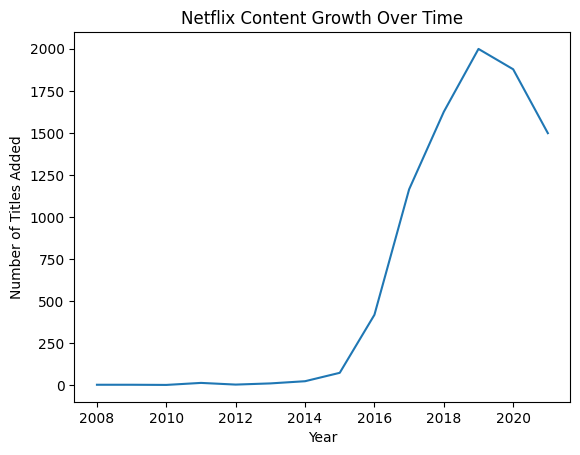

In [5]:
year_counts = df["year_added"].value_counts().sort_index()

plt.figure()
year_counts.plot(kind="line")
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

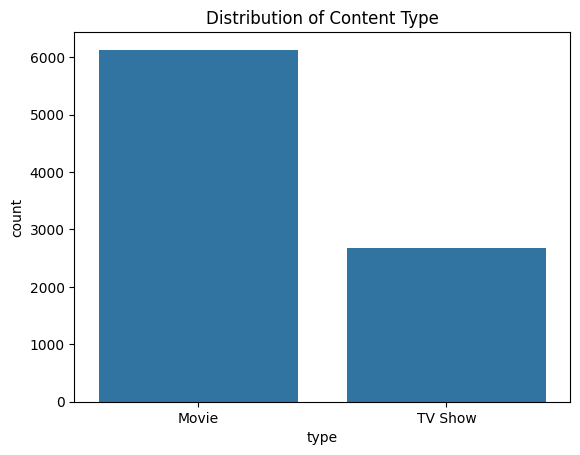

In [6]:
plt.figure()
sns.countplot(data=df, x="type")
plt.title("Distribution of Content Type")
plt.show()

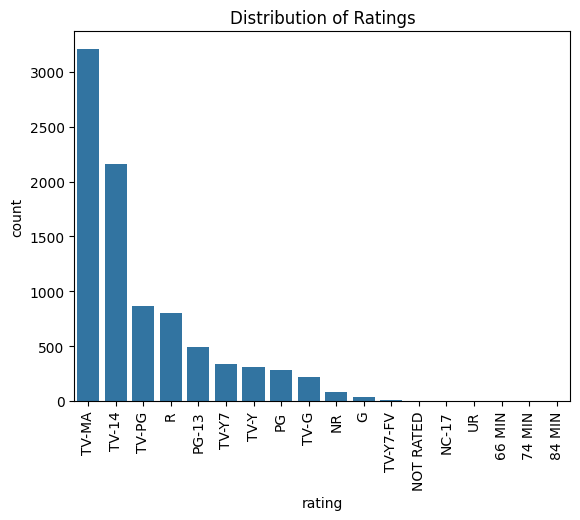

In [7]:
plt.figure()
sns.countplot(
    data=df,
    x="rating",
    order=df["rating"].value_counts().index
)
plt.xticks(rotation=90)
plt.title("Distribution of Ratings")
plt.show()

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'genre_list', 'country_list', 'year_added'],
      dtype='object')

In [10]:
df["rating"].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 MIN', '84 MIN', '66 MIN', 'NR',
       'NOT RATED', 'TV-Y7-FV', 'UR'], dtype=object)

In [11]:
# Fix incorrect rating entries that contain 'MIN'
df.loc[df["rating"].str.contains("MIN", na=False), "rating"] = "Unknown"

In [12]:
df["rating"].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'Unknown', 'NR', 'NOT RATED', 'TV-Y7-FV',
       'UR'], dtype=object)

In [13]:
adult_ratings = ["R", "NC-17", "TV-MA"]

df["rating_binary"] = df["rating"].apply(
    lambda x: 1 if x in adult_ratings else 0
)

df["rating_binary"].value_counts()

rating_binary
0    4798
1    4009
Name: count, dtype: int64

In [14]:
df["rating_category"] = df["rating"].apply(
    lambda x: "Adult" if x in adult_ratings else "General"
)

df["rating_category"].value_counts()

rating_category
General    4798
Adult      4009
Name: count, dtype: int64

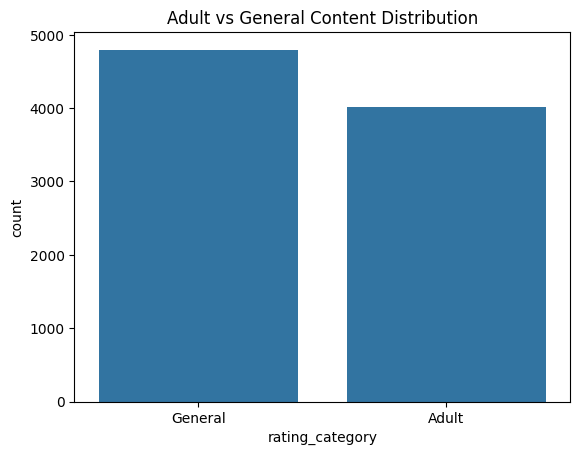

In [15]:
plt.figure()
sns.countplot(data=df, x="rating_category")
plt.title("Adult vs General Content Distribution")
plt.show()

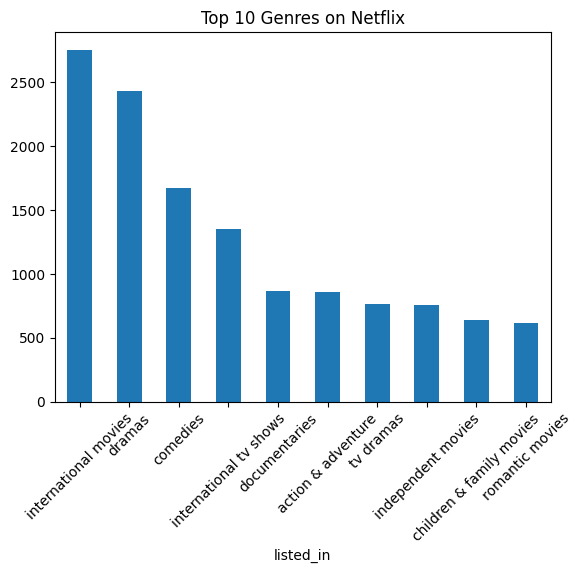

In [16]:
genre_df = df.copy()
genre_df["listed_in"] = genre_df["listed_in"].str.split(",")
genre_df = genre_df.explode("listed_in")
genre_df["listed_in"] = genre_df["listed_in"].str.strip()

top_genres = genre_df["listed_in"].value_counts().head(10)

plt.figure()
top_genres.plot(kind="bar")
plt.title("Top 10 Genres on Netflix")
plt.xticks(rotation=45)
plt.show()

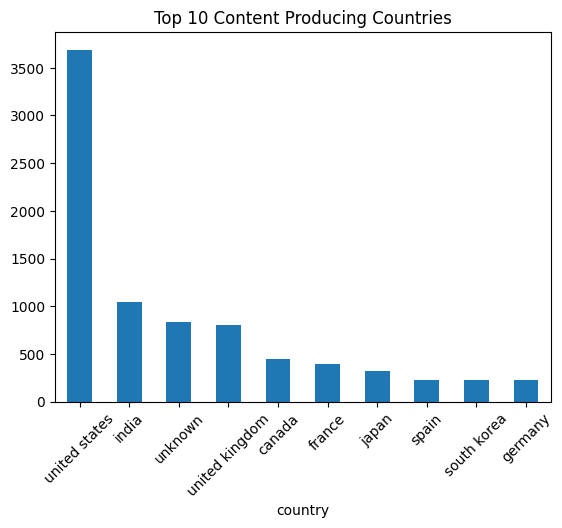

In [17]:
country_df = df.copy()
country_df["country"] = country_df["country"].str.split(",")
country_df = country_df.explode("country")
country_df["country"] = country_df["country"].str.strip()

top_countries = country_df["country"].value_counts().head(10)

plt.figure()
top_countries.plot(kind="bar")
plt.title("Top 10 Content Producing Countries")
plt.xticks(rotation=45)
plt.show()

In [18]:
def categorize_duration(duration):
    if isinstance(duration, str):
        if "min" in duration:
            minutes = int(duration.split()[0])
            if minutes < 60:
                return "Short Movie"
            elif minutes < 120:
                return "Medium Movie"
            else:
                return "Long Movie"
        elif "Season" in duration:
            seasons = int(duration.split()[0])
            if seasons == 1:
                return "Single Season Show"
            else:
                return "Multi-Season Show"
    return "Unknown"

df["Content_Length_Category"] = df["duration"].apply(categorize_duration)

df["Content_Length_Category"].value_counts()

Content_Length_Category
Medium Movie          4472
Single Season Show    1793
Long Movie            1198
Multi-Season Show      883
Short Movie            458
Unknown                  3
Name: count, dtype: int64

In [19]:
df["Original_vs_Licensed"] = df["title"].apply(
    lambda x: "Original" if isinstance(x, str) and "Netflix" in x else "Licensed"
)

df["Original_vs_Licensed"].value_counts()

Original_vs_Licensed
Licensed    8803
Original       4
Name: count, dtype: int64

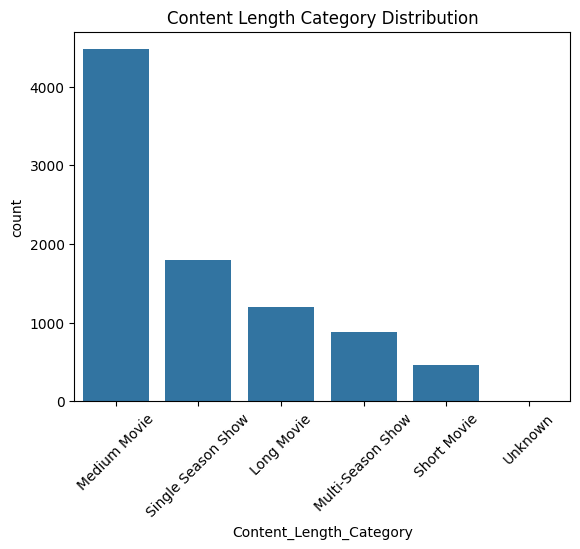

In [20]:
plt.figure()
sns.countplot(
    data=df,
    x="Content_Length_Category",
    order=df["Content_Length_Category"].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Content Length Category Distribution")
plt.show()

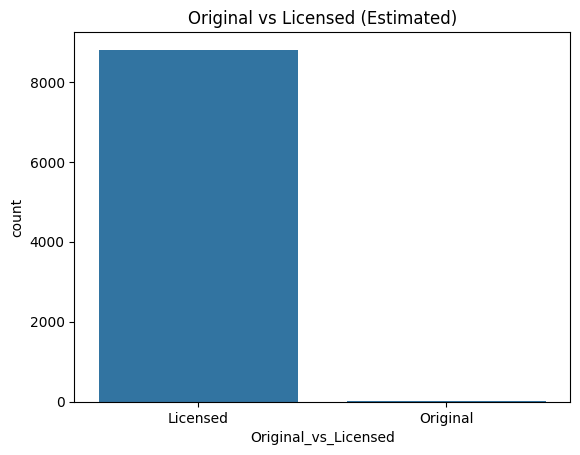

In [21]:
plt.figure()
sns.countplot(data=df, x="Original_vs_Licensed")
plt.title("Original vs Licensed (Estimated)")
plt.show()

In [23]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre_list,country_list,year_added,rating_binary,rating_category,Content_Length_Category,Original_vs_Licensed
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,PG-13,90 min,documentaries,"As her father nears the end of his life, filmm...",['documentaries'],['united states'],2021.0,0,General,Medium Movie,Licensed
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t...","['international tv shows', 'tv dramas', 'tv my...",['south africa'],2021.0,1,Adult,Multi-Season Show,Licensed
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...,"['crime tv shows', 'international tv shows', '...",['unknown'],2021.0,1,Adult,Single Season Show,Licensed
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,TV-MA,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo...","['docuseries', 'reality tv']",['unknown'],2021.0,1,Adult,Single Season Show,Licensed
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,TV-MA,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...,"['international tv shows', 'romantic tv shows'...",['india'],2021.0,1,Adult,Multi-Season Show,Licensed


In [24]:
df.to_csv("../data/netflix_milestone2.csv", index=False)